In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cleaned_e-commerce_dataset.csv')
df

,customer_id,order_id,age,gender,city,product_category,price,quantity,discount_percent,order_date,payment_method,customer_rating,delivery_days,returned
0,1171.0,363.0,21.0,Male,Hyderabad,Sports,1912.090000,3.0,0.0,2021-02-23,NetBanking,3.0,14.0,Yes
1,1047.0,496.0,33.0,Male,Mumbai,Electronics,268.350000,4.0,20.0,2021-09-02,COD,3.0,10.0,Yes
2,1185.0,206.0,42.0,Female,Pune,Sports,230.390000,1.0,10.0,2022-07-10,Card,2.0,4.0,Yes
3,1135.0,113.0,54.0,Male,Delhi,Electronics,1615.110000,5.0,0.0,2022-05-18,Card,3.0,12.0,Yes
4,1092.0,311.0,45.0,Male,Pune,Electronics,461.190000,2.0,0.0,2023-08-31,UPI,5.0,3.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,1092.0,3.0,47.0,Female,Pune,Electronics,518.430000,1.0,20.0,2024-08-15,COD,3.0,8.0,No
596,1095.0,259.0,45.0,Female,Pune,Sports,1274.447403,4.0,0.0,2024-02-23,UPI,2.0,14.0,No
597,1016.0,362.0,49.0,Male,Chennai,Electronics,1274.447403,3.0,0.0,2023-09-05,Card,3.0,12.0,Yes
598,1150.0,396.0,73.0,Male,Pune,Grocery,925.720000,3.0,0.0,2023-12-23,NetBanking,3.0,2.0,No


## 1. What is the distribution of customers age?

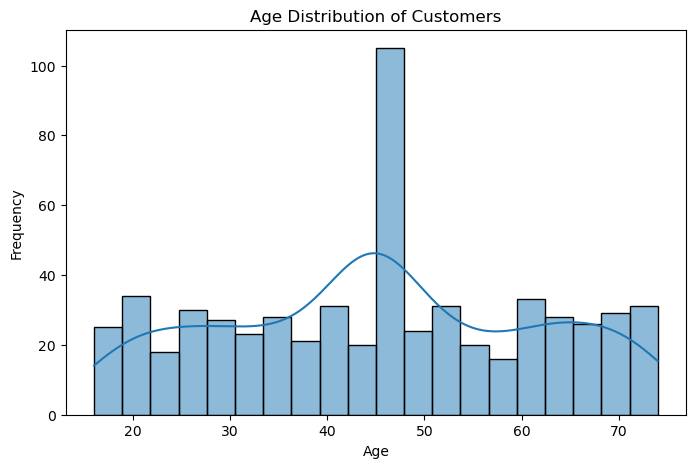

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Insights:
 - age group between 40 to 50 has major product perchase

## 2.What is the gender distribution of customers?

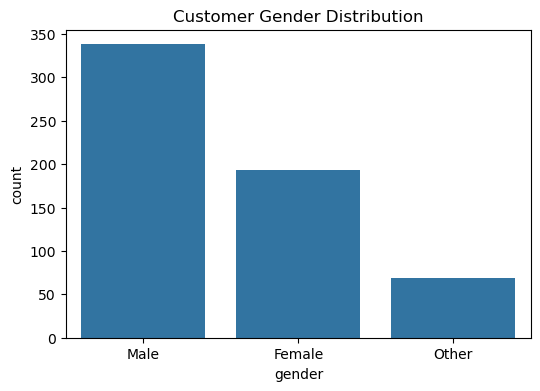

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", data=df)
plt.title("Customer Gender Distribution")
plt.show()

### Insights:
 - Male dominates the customer base

## 3. Which cities generates the most orders?

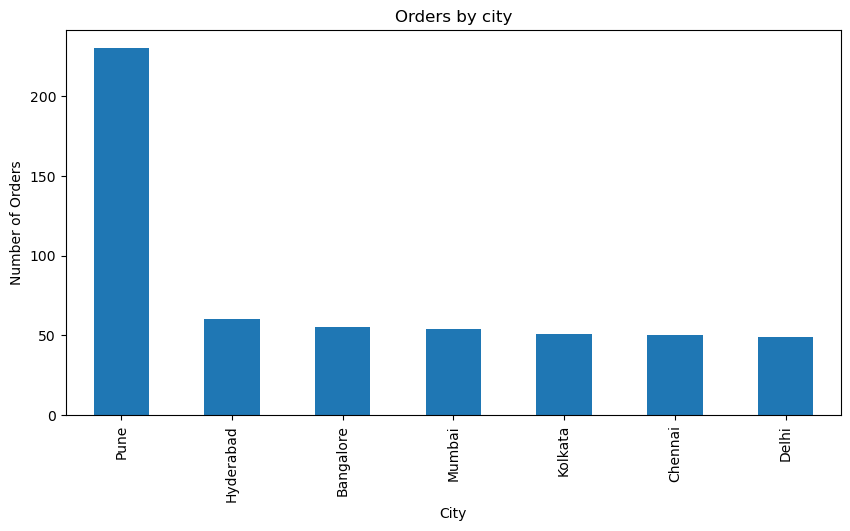

In [5]:
plt.figure(figsize=(10,5))
df["city"].value_counts().plot(kind="bar")
plt.title("Orders by city")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.show()

### Insights:
 - Pune is the top performing city 

## 4. Which product categories are most popular?

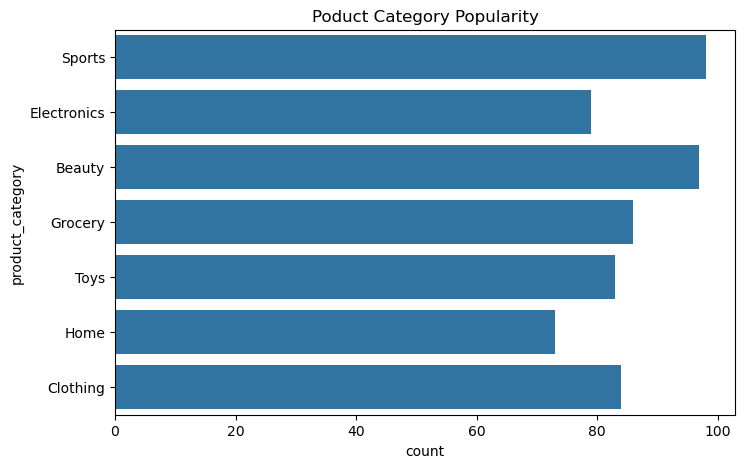

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(y="product_category", data=df)
plt.title("Poduct Category Popularity")
plt.show()

### Insights:
 - Sports and Beauty Category are most popular

## 5. What is the price distribution of product?

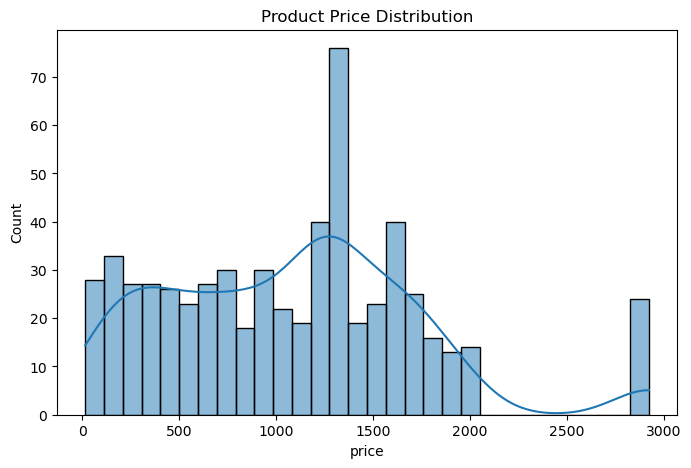

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Product Price Distribution")
plt.show()

### Insights:
 - Understand pricing properties and outliers

## 6. How does price vary across product categories?

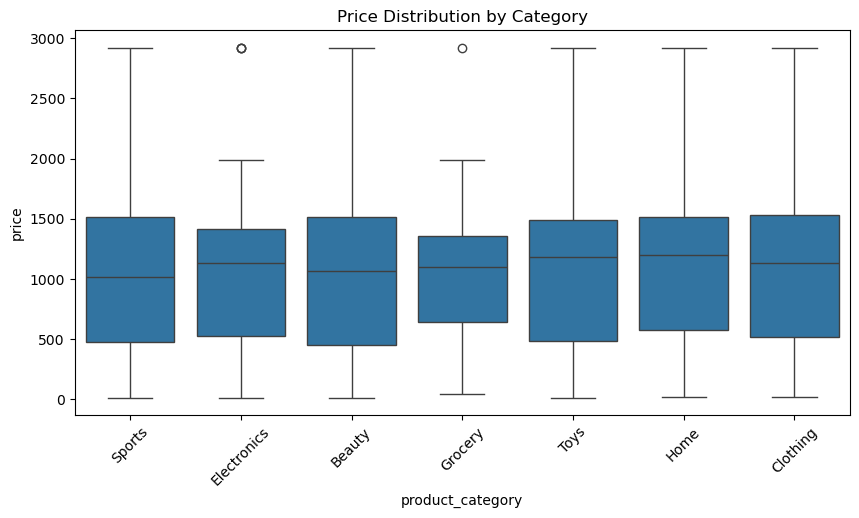

In [8]:
plt.figure(figsize=(10,5))
sns.boxplot(x="product_category", y="price", data=df)
plt.title("Price Distribution by Category")
plt.xticks(rotation=45)
plt.show()

### Insights:
 - Compare expesive vs cheap categories.

## 7. Which payment method is used most frequently?

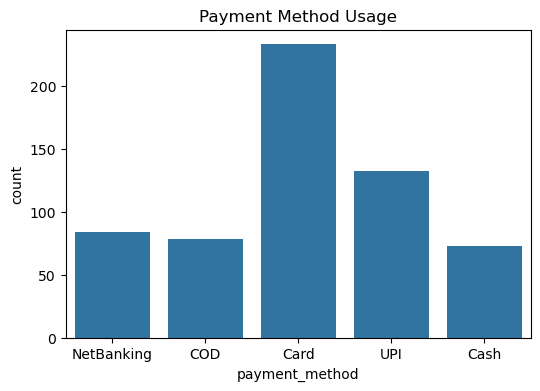

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="payment_method", data=df)
plt.title("Payment Method Usage")
plt.show()

### Insights:
 - Understanding customer payment prefrences (Card).

## 8. Does discount affect product price?

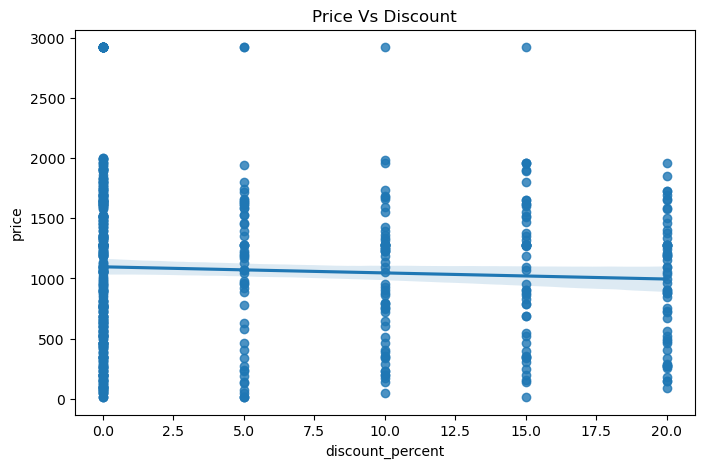

In [10]:
plt.figure(figsize=(8,5))
sns.regplot(x="discount_percent", y="price",data=df)
plt.title("Price Vs Discount")
plt.show()

### Insights:
 - Analyzing relationship between discount and price.

## 9. What is the distribution of delivery time?

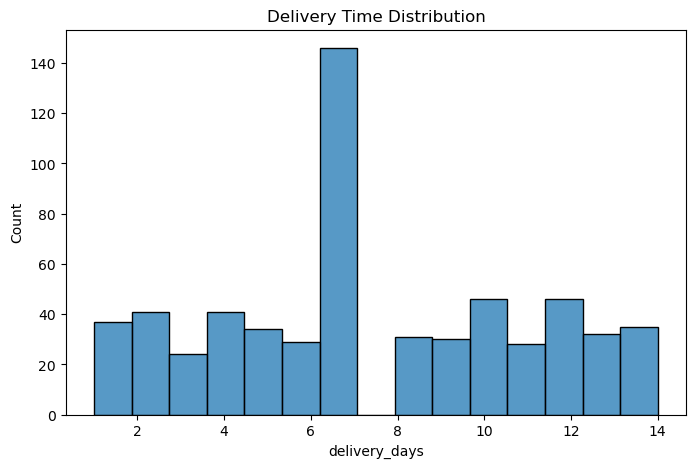

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["delivery_days"], bins=15)
plt.title("Delivery Time Distribution")
plt.show()

### Insights:
 - Identify typical delivery duration.

## 10. Does delivery time affect customer ratings?

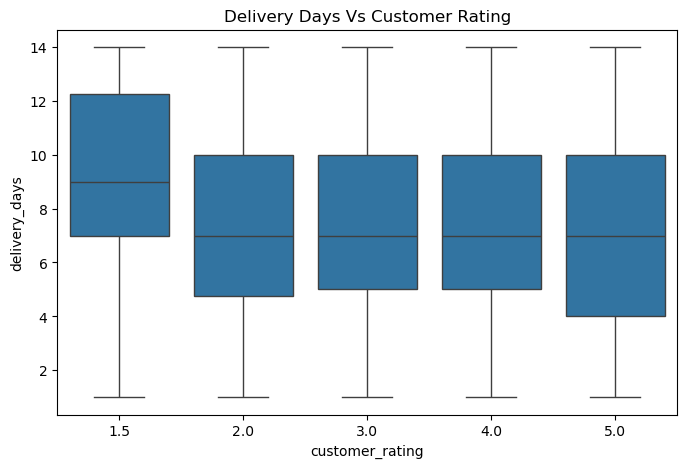

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x="customer_rating", y="delivery_days", data=df)
plt.title("Delivery Days Vs Customer Rating")
plt.show()

### Insights:
 - See if the faster delivery leads to higher ratings.

## 11. Which product categories have the highest average price?

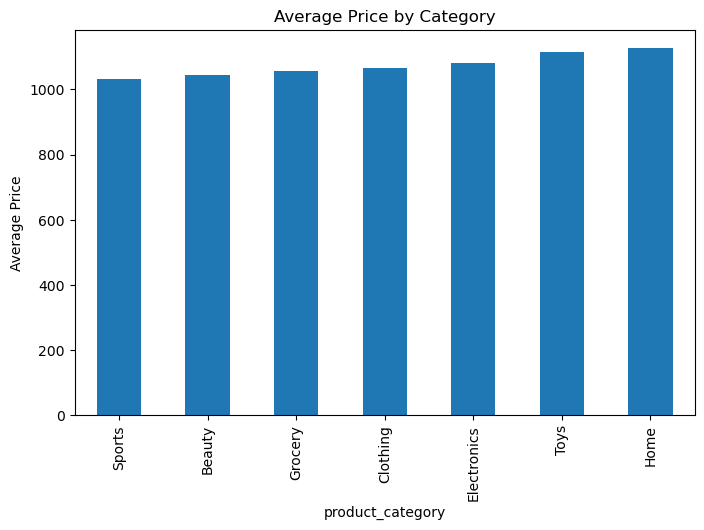

In [13]:
category_price = df.groupby("product_category")["price"].mean().sort_values()

category_price.plot(kind="bar", figsize=(8,5))
plt.title("Average Price by Category")
plt.ylabel("Average Price")
plt.show()

### Insights: 
 - Identifying premium categories.

## 12. What is the relationship between quantity and price?

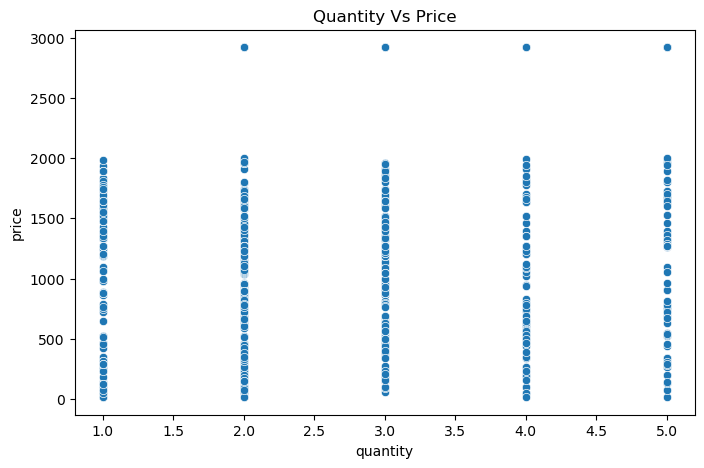

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="quantity", y="price", data=df)
plt.title("Quantity Vs Price")
plt.show()

### Insights:
 - See if bulk purchases involve expensive products.

## 14. Which cities have the highest average delivery time?

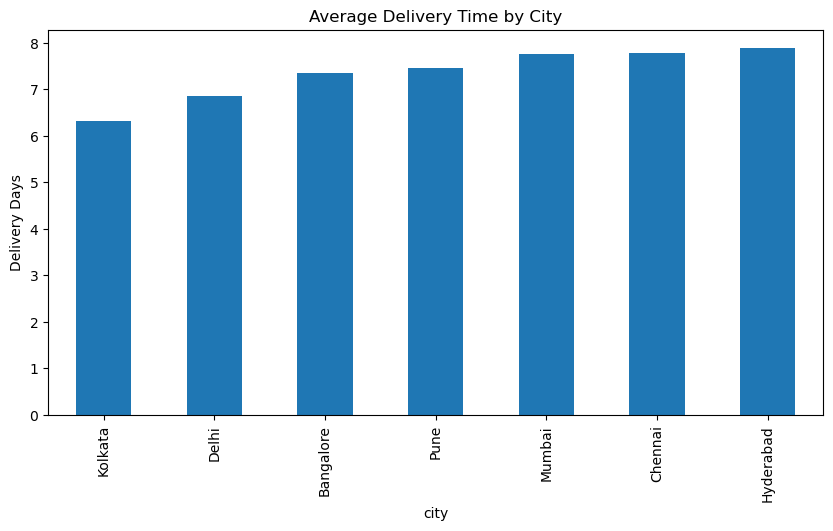

In [15]:
delivery_city = df.groupby("city")["delivery_days"].mean().sort_values()

delivery_city.plot(kind="bar", figsize=(10,5))
plt.title("Average Delivery Time by City")
plt.ylabel("Delivery Days")
plt.show()

### Insights:
 - Identify logistics issues by city.

## 15. Correlation between numerical variables

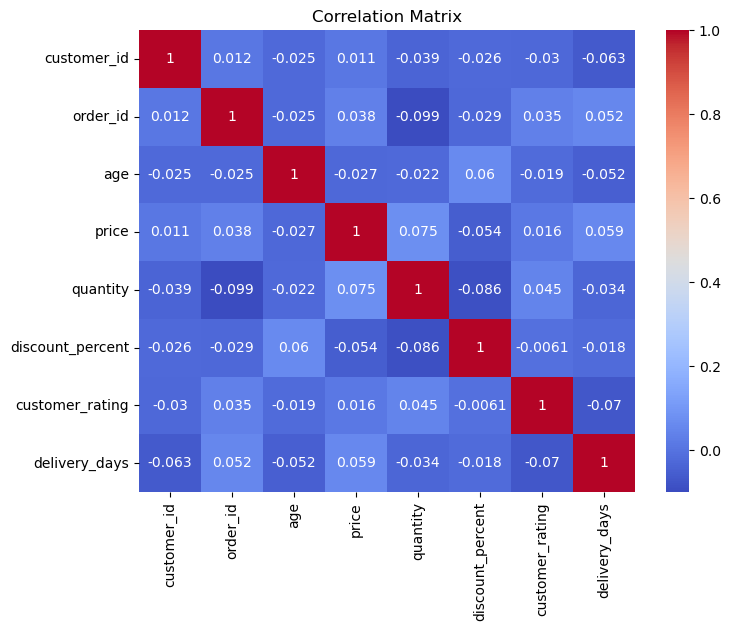

In [16]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=["number"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Insights:
 - Identify relationships between numeric variables.

## 16. Pairplot (Understand Relationships Between Variables)

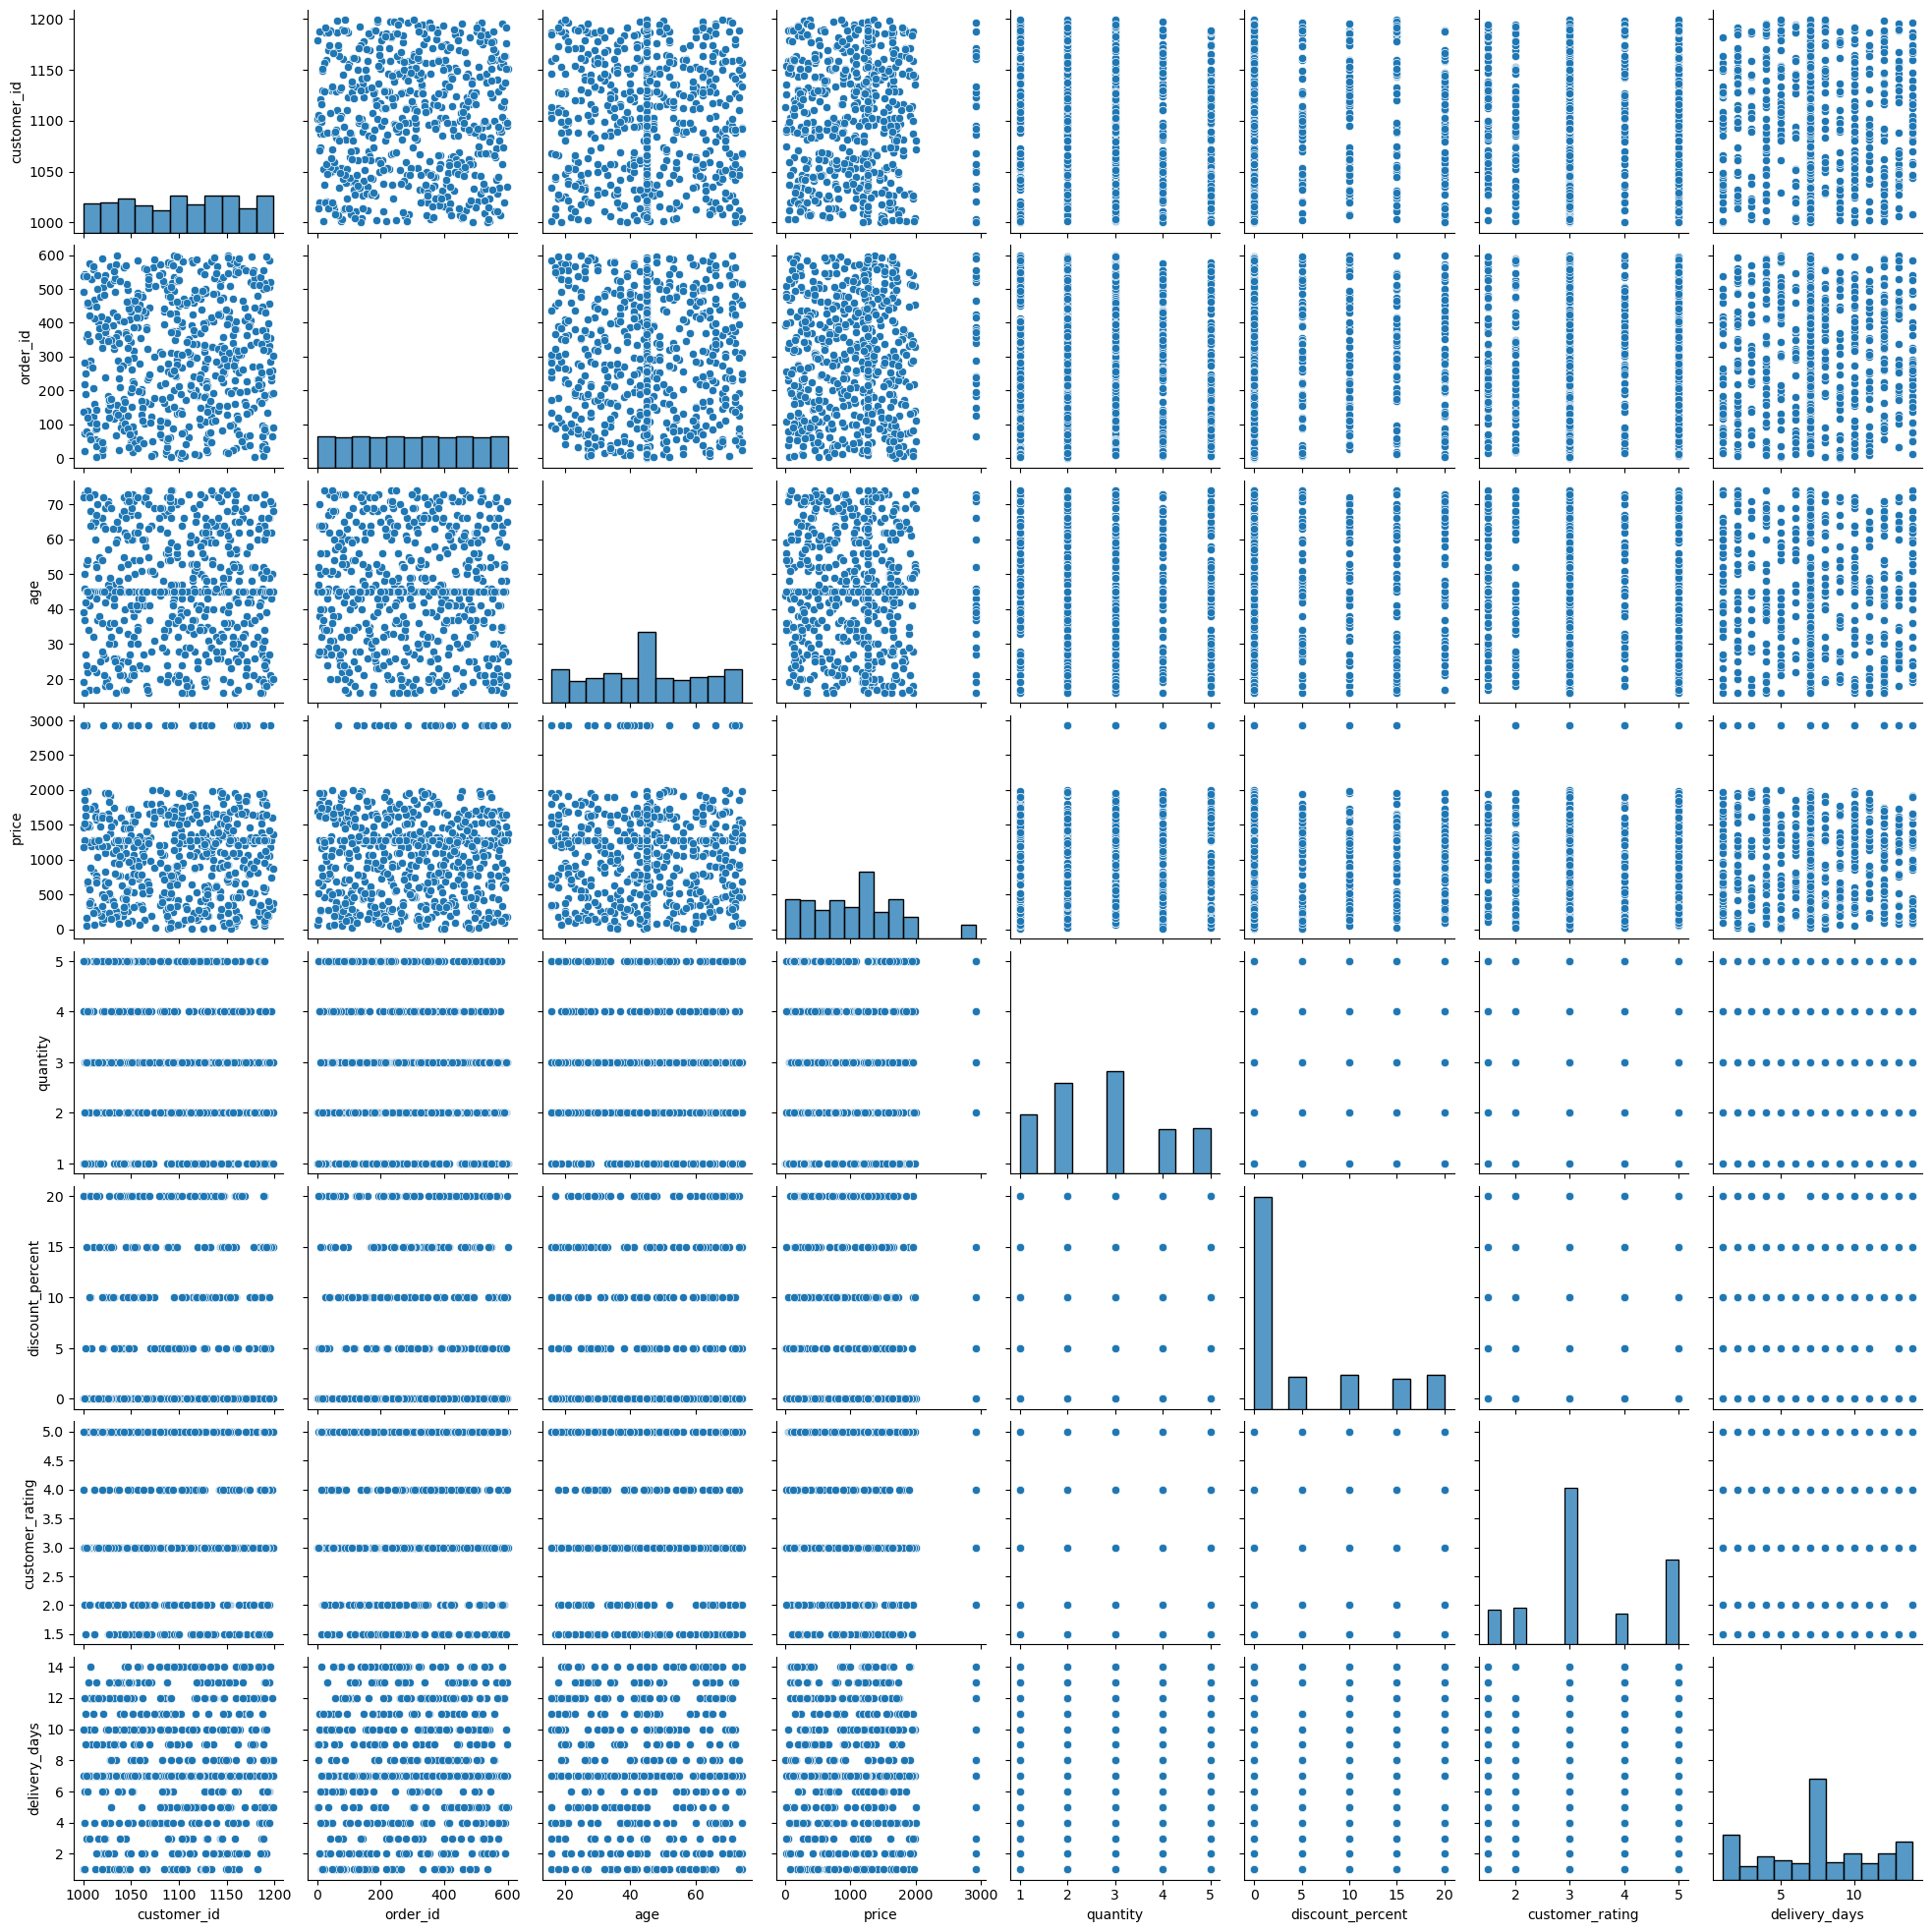

In [17]:
numeric_df = df.select_dtypes(include=["number"])

sns.pairplot(numeric_df)
plt.show()

### Insights: Helps Identify:
 - correlations

 - clusters

 - outliers

 - relationships between features

## 17. Violin Plot (Better Than Boxplot)

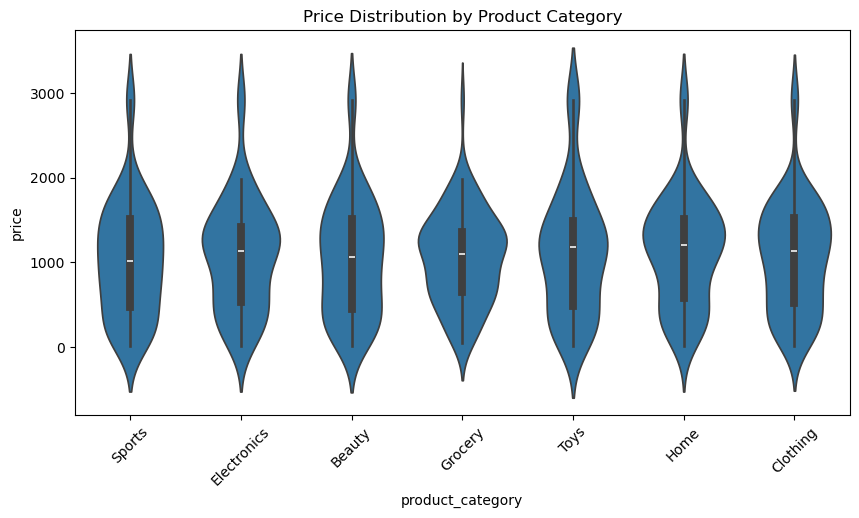

In [18]:
plt.figure(figsize=(10,5))
sns.violinplot(x="product_category", y="price", data=df)
plt.xticks(rotation=45)
plt.title("Price Distribution by Product Category")
plt.show()

### Insights:
 - It Shows:
 - spread of prices

 - category price variation

 - skewed distributions

## 18. Category vs Average Revenue

In [19]:
df["total_value"] = df["price"] * df["quantity"]

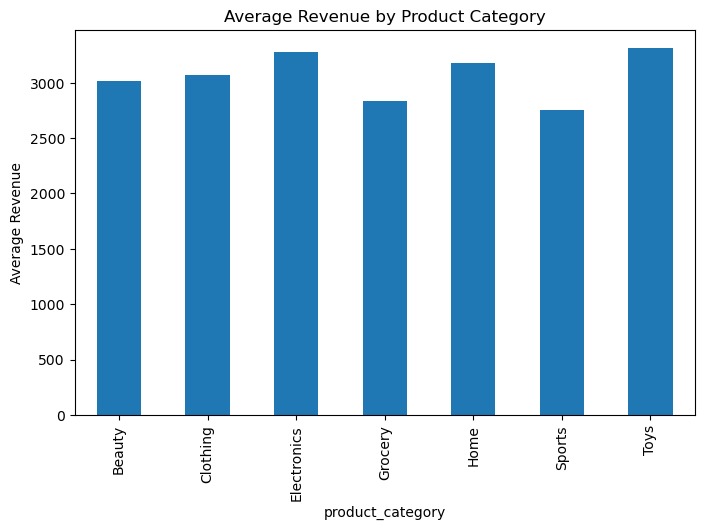

In [20]:
category_revenue = df.groupby("product_category")["total_value"].mean()
category_revenue.plot(kind="bar", figsize=(8,5))
plt.title("Average Revenue by Product Category")
plt.ylabel("Average Revenue")
plt.show()

### Insights:
 - Identify most profitable categories.

## 19. Customer Rating vs Product Category

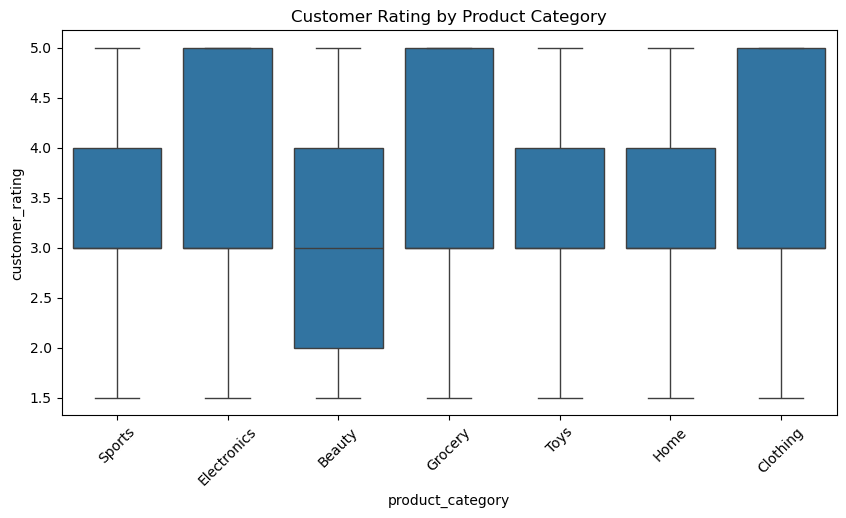

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(x="product_category", y="customer_rating", data=df)
plt.xticks(rotation=45)
plt.title("Customer Rating by Product Category")
plt.show()

### Insights:
 - Shows which categories get better customer satisfaction.

## 20. Heatmap of Orders by City & Category

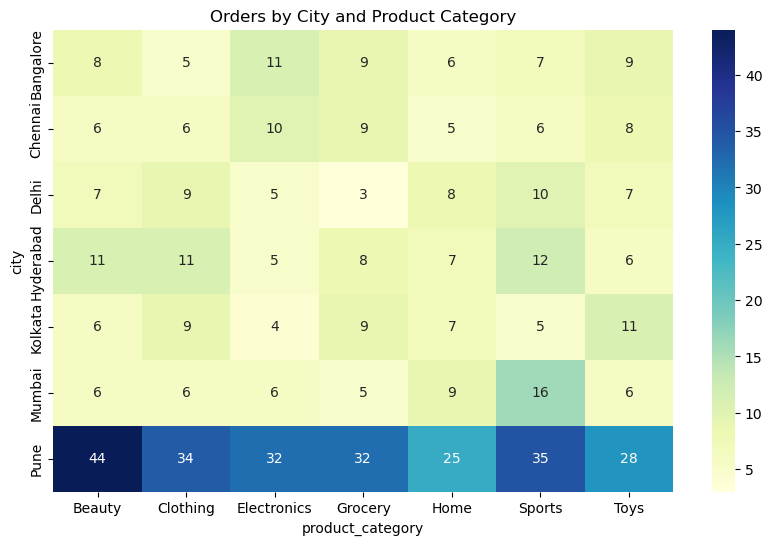

In [22]:
pivot = pd.crosstab(df["city"], df["product_category"])
plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt="d")
plt.title("Orders by City and Product Category")
plt.show()

### Insights: 
 - identify:
 - city demand patterns

 - regional product preferences

## 21. Monthly Order Trend

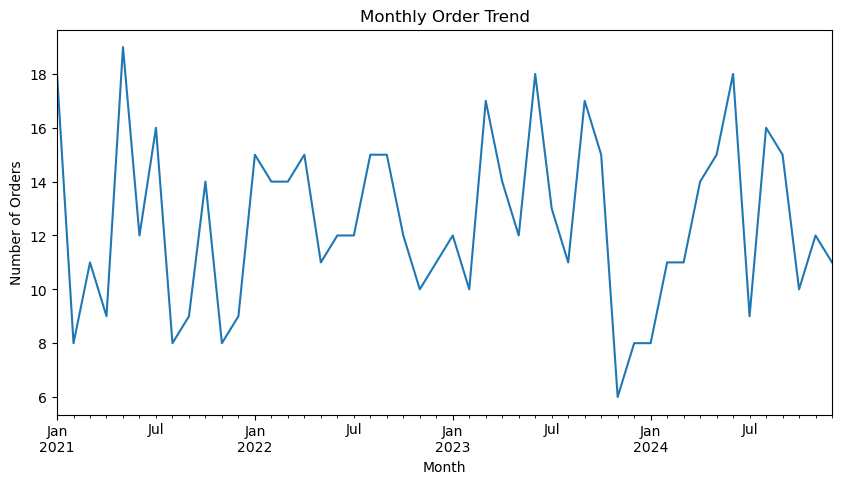

In [23]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

df["month"] = df["order_date"].dt.to_period("M")

monthly_orders = df.groupby("month").size()

monthly_orders.plot(figsize=(10,5))

plt.title("Monthly Order Trend")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.show()

### Insights:
 - Shows sales growth trends over time.